## What is Prophet?

Prophet is a time series forecasting model developed by Meta.

It is designed to handle:
- Trend
- Seasonality
- Holidays / events



### Simple Idea:
Prophet automatically finds patterns in data

You don’t need deep statistical knowledge to use it.



### Why Prophet?

- Easy to use
- Works well on business data
- Handles missing values and outliers

<img src="Prophet_working.png" alt="Time Series info" width="600" height="800" />


## Prophet for Time Series

Prophet models time series data as a combination of components.



### Formula Idea:

Time Series = Trend + Seasonality + Holidays + Error



### Components:

1. Trend:
   Long-term growth or decline

2. Seasonality:
   Repeating patterns (daily, weekly, yearly)

3. Holidays:
   Special events affecting data



### Key Idea:
Prophet automatically detects these components and combines them

<img src="Prophet_Time Series.png" alt="Time Series info" width="900" height="600" />


In [1]:
import pandas as pd
import plotly.graph_objects as go
from prophet import Prophet
import warnings

warnings.filterwarnings("ignore")

e:\A_VS_CODE\a-vs-code-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Fetch Real Dataset & The Prophet Formatting Rule

# Using the classic Peyton Manning Wikipedia page views dataset
url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
df = pd.read_csv(url)

###  Data Formatting for Prophet

Unlike standard machine learning models, Meta's Prophet requires a very specific data structure to function. The dataset must contain exactly two columns: 
* `ds`: The datestamp column (must be in YYYY-MM-DD or YYYY-MM-DD HH:MM:SS format).
* `y`: The numeric measurement we want to forecast (e.g., inventory demand, server load).

This strict formatting allows Prophet's backend to automatically detect daily, weekly, and yearly seasonalities.

In [3]:
df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


In [4]:
# The date column must be called 'ds' and the target column must be called 'y'.
# This dataset already follows that format. Otherwise, we would need to rename columns.
print(f"Total historical days: {len(df)}")

Total historical days: 2905


###  Injecting Holiday & Event Intelligence

Standard forecasting models often fail spectacularly during major holidays or events because human behavior changes drastically. Prophet allows us to inject explicit holiday calendars into the model. By doing this, the algorithm learns that sudden spikes or drops on specific dates are not random errors, but predictable recurring events.

In [9]:
# Feature Engineering - The "Holidays" Superpower

# When special events happen (like sales, festivals, sports events),
# the normal pattern changes.
# Prophet allows us to provide these dates so it can adjust predictions.

playoffs = pd.DataFrame({
  'holiday': 'playoff',
  'ds': pd.to_datetime(['2008-01-13', '2009-01-03', '2010-01-16',
                        '2010-01-24', '2010-02-07', '2011-01-08',
                        '2013-01-12', '2014-01-12', '2014-01-19',
                        '2014-02-02', '2015-01-11', '2016-01-17',
                        '2016-01-24', '2016-02-07']),
  'lower_window': 0,
  'upper_window': 1, # Effect continues for 1 day after the event
})

superbowls = pd.DataFrame({
  'holiday': 'superbowl',
  'ds': pd.to_datetime(['2010-02-07', '2014-02-02', '2016-02-07']),
  'lower_window': 0,
  'upper_window': 1,
})

events = pd.concat((playoffs, superbowls))

In [11]:
events

,holiday,ds,lower_window,upper_window
0,playoff,2008-01-13,0,1
1,playoff,2009-01-03,0,1
2,playoff,2010-01-16,0,1
3,playoff,2010-01-24,0,1
4,playoff,2010-02-07,0,1
5,playoff,2011-01-08,0,1
6,playoff,2013-01-12,0,1
7,playoff,2014-01-12,0,1
8,playoff,2014-01-19,0,1
9,playoff,2014-02-02,0,1


### Model Configuration: Understanding Prophet Parameters

When initializing the Prophet forecasting model, several key parameters are customized to understand the specific behavior of the dataset:

* **`holidays=events`**: Injects a custom calendar of known events. This explicitly tells the algorithm that sudden spikes or dips on these specific dates are expected behaviors, rather than random anomalies.
* **`yearly_seasonality=True`**: Instructs the model to capture and learn annual repeating patterns across the months of the year.
* **`weekly_seasonality=True`**: Captures day-of-the-week patterns to differentiate between weekday and weekend trends.
* **`daily_seasonality=False`**: Disabled because the dataset is aggregated at the daily level (YYYY-MM-DD), rather than at the hourly or minute level.
* **`changepoint_prior_scale=0.05`**: A crucial flexibility parameter that dictates how quickly the main trend is allowed to change direction. A balanced value of 0.05 prevents the model from overfitting to minor fluctuations while still adapting to genuine, long-term shifts in the data.

In [12]:
# Build & Train the Prophet Model

# We tell the model:
# - There is yearly pattern
# - There is weekly pattern
# - No daily pattern needed
# - Include event effects
m = Prophet(holidays=events, 
            yearly_seasonality=True, 
            weekly_seasonality=True, 
            daily_seasonality=False,
            changepoint_prior_scale=0.05) # Controls how quickly trend can change

m.fit(df)

10:19:01 - cmdstanpy - INFO - Chain [1] start processing
10:19:01 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# Creating the Future & Predicting

# This creates future dates automatically (next 365 days)
future = m.make_future_dataframe(periods=365)

# Generate predictions
forecast = m.predict(future)

# Important columns in forecast:
# 'ds' -> Date
# 'yhat' -> Predicted value
# 'yhat_lower' and 'yhat_upper' -> Confidence interval

In [17]:
forecast['ds']

0      2007-12-10
1      2007-12-11
2      2007-12-12
3      2007-12-13
4      2007-12-14
          ...    
3265   2017-01-15
3266   2017-01-16
3267   2017-01-17
3268   2017-01-18
3269   2017-01-19
Name: ds, Length: 3270, dtype: datetime64[ns]

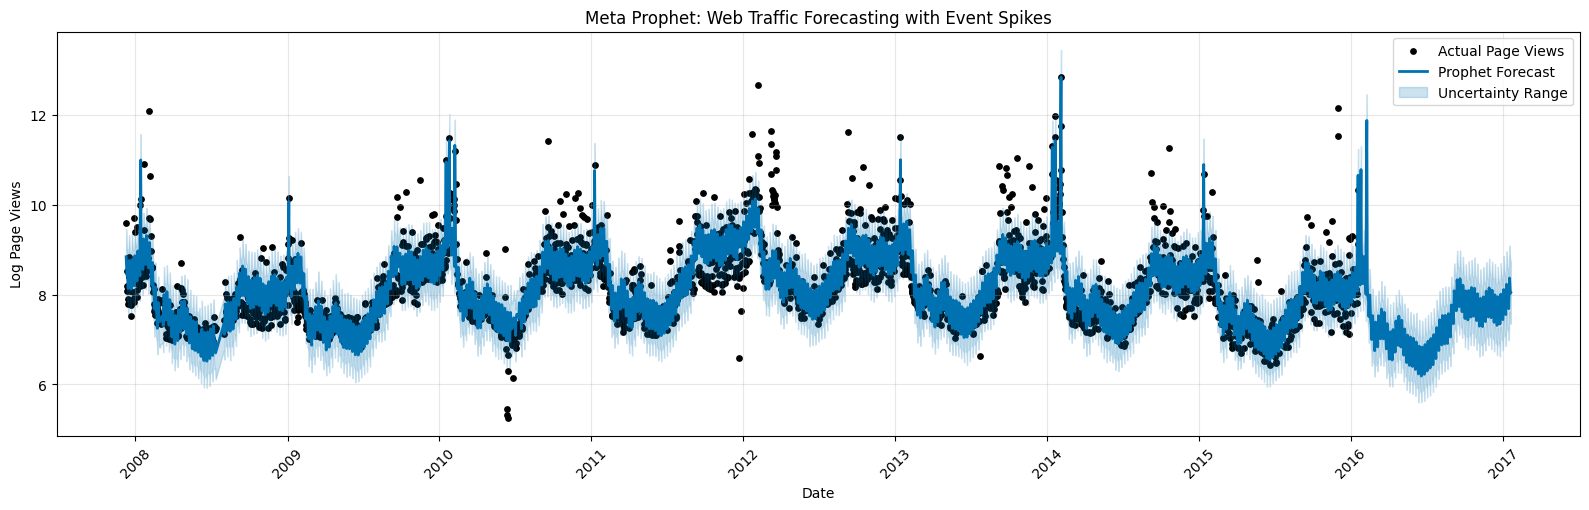

In [ ]:
import matplotlib.pyplot as plt

# Ensure datetime format
df['ds'] = pd.to_datetime(df['ds'])
forecast['ds'] = pd.to_datetime(forecast['ds'])

# Create figure
plt.figure(figsize=(16, 5))

# Actual Historical Data (Black Dots)
plt.scatter(
    df['ds'],
    df['y'],
    color='black',
    s=15,
    label='Actual Page Views'
)

# Prophet Expected Prediction (Blue Line)
plt.plot(
    forecast['ds'],
    forecast['yhat'],
    color='#0072B2',
    linewidth=2,
    label='Prophet Forecast'
)

# Confidence Intervals (Light Blue Shaded Area)
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='#0072B2',
    alpha=0.2,
    label='Uncertainty Range'
)

# Labels and Title
plt.title('Meta Prophet: Web Traffic Forecasting with Event Spikes')
plt.xlabel('Date')
plt.ylabel('Log Page Views')

# Style
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Rotate dates for better readability
plt.xticks(rotation=45)

# Show Plot
plt.show()

###  Forecasting & Understanding Uncertainty (Confidence Intervals)

Using the `make_future_dataframe` function, the model automatically generates a blank calendar for the next 365 days and populates it with predictions. 

**How to read the Prophet Graph:**
* **Black Dots:** The actual historical data points.
* **Dark Blue Line:** The model's exact prediction (`yhat`) for both the past and the future.
* **Light Blue Band:** This is the **Confidence Interval** (Uncertainty). It shows the upper and lower bounds of the forecast, giving business stakeholders a realistic best-case and worst-case scenario rather than just a single guessed number.

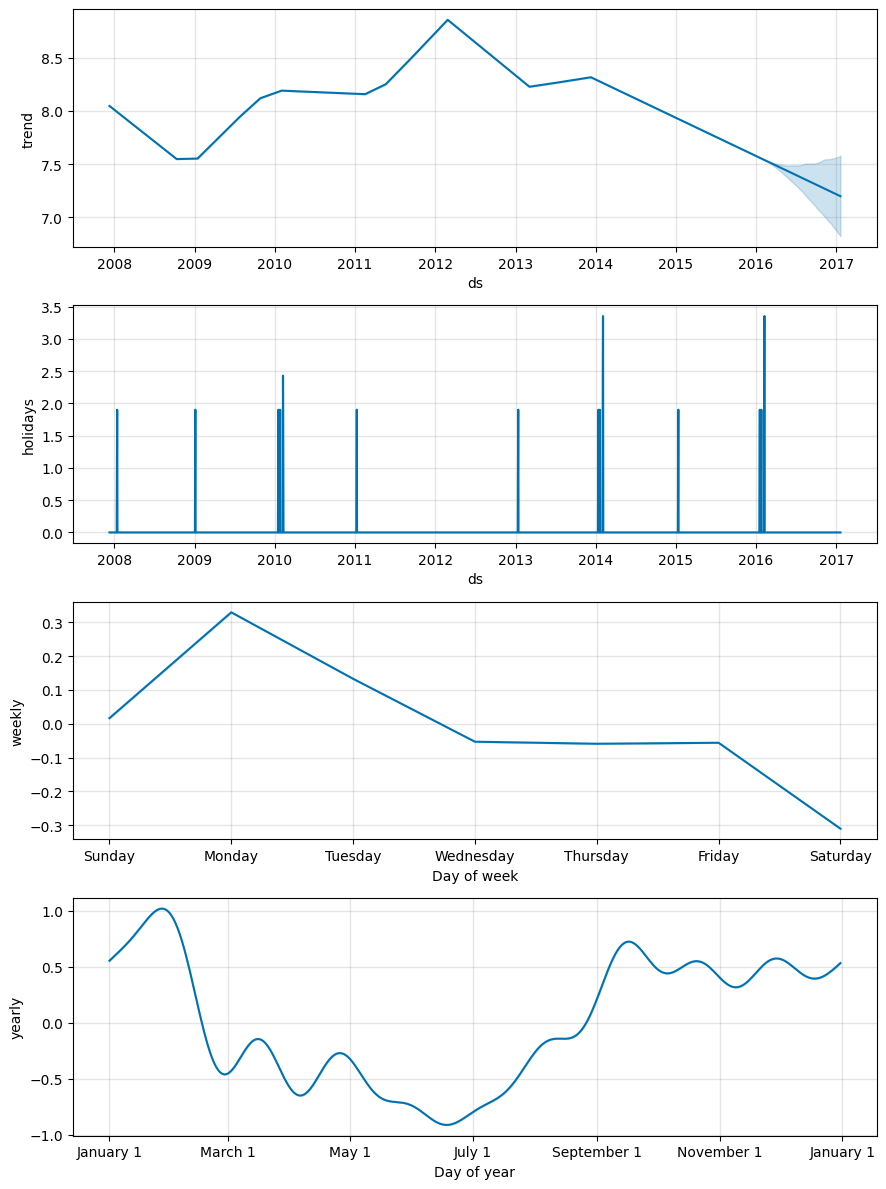

In [ ]:
# Bonus: Prophet built-in component plots (run in Jupyter Notebook)
fig_components = m.plot_components(forecast)

###  Deconstructing the Forecast: Understanding the Components Plot

The `plot_components` function is what makes Prophet incredibly valuable for business intelligence. It breaks down the overall complex forecast into separate, understandable drivers.

By analyzing the output graphs, we can observe:

* **Trend (Top Panel):** This shows the overarching direction of the data over time, ignoring all short-term seasonal bumps and holidays. It answers the question: "Is our target generally growing or shrinking over the years?"

* **Holidays/Events (Second Panel):** This isolates the exact impact of the specific events we fed into the model. The spikes or dips show how much a specific holiday pulls the data up or pushes it down from the normal trend.

* **Weekly Seasonality (Third Panel):** This breaks down the typical behavior across a 7-day week. It helps identify which exact days (e.g., weekends vs. weekdays) consistently drive the highest or lowest numbers.

* **Yearly Seasonality (Bottom Panel):** This illustrates the annual lifecycle. It clearly maps out which months of the year experience peak surges and which months suffer seasonal slumps, regardless of the overall trend.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prophet model ki predictions 'yhat' column mein hoti hain
# Ensure we are only comparing the dates that were in our actual data (not future dates)
actuals = df['y']  # Aapke original dataframe ka 'y' column
predictions = forecast['yhat'][:len(df)]  # Forecast dataframe se matching rows ki predictions

mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 0.32
Root Mean Squared Error (RMSE): 0.46


### Model Evaluation: Error Metrics Analysis
To objectively measure the forecasting accuracy of the Prophet model, standard regression metrics are calculated comparing the predicted values against the actual historical data:

* **Mean Absolute Error (MAE): 0.32**
  This indicates that, on average, the model's forecasts deviate from the actual real-world values by only 0.32 units. 
* **Root Mean Squared Error (RMSE): 0.46**
  RMSE penalizes larger errors more heavily. The fact that the RMSE (0.46) is very close to the MAE (0.32) proves that the model is highly consistent and is not making extreme, outlier mistakes.


⚙️ The End-to-End Pipeline

Strict Formatting: We formatted our raw data to strictly contain a ds (datetime) column and a y (target) column, the required standard for Prophet to automate its internal splitting.

Holiday Engineering: We manually created a "calendar" dataframe of historical and future Super Bowl and Playoff dates. We fed this list to the model so it could explicitly learn the impact of these specific days.

Additive Training: The model analyzed the data and automatically calculated the baseline growth (trend) while separately learning the "spikes" associated with the holidays we provided.

Future Generation: Using the make_future_dataframe utility, we automatically generated a blank calendar for the next 365 days, which the model populated with predictions, accounting for upcoming holidays.

Uncertainty Visualization: We plotted the forecast alongside "Confidence Intervals" (the light blue band), giving business stakeholders a realistic best-case and worst-case scenario.



<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>

In [ ]:
How do businesses avoid inventory stockouts or server crashes during major holidays and events? 📈📅

Traditional forecasting models often struggle when customer behavior suddenly changes during festivals, sales, or special events. That’s where Meta Prophet becomes useful.

Here’s how this forecasting pipeline works:

🔹 Trend & Seasonality Analysis
Instead of treating data as a single line, Prophet separates long-term trends, yearly patterns, and weekly behavior. This helps identify patterns like weekend traffic drops or seasonal demand increases.

🔹 Holiday & Event Awareness
Special events and holidays are added directly into the model using custom event calendars. This allows the system to learn recurring demand spikes instead of treating them as random anomalies.

🔹 Flexible Trend Detection
Using changepoint_prior_scale=0.05, the model can adapt to real market changes while avoiding overreaction to short-term noise.

🔹 Forecasting with Uncertainty
Rather than predicting a single value, the model generates a 365-day forecast with confidence intervals, helping businesses prepare for both high-demand and low-demand scenarios.

🔹 Model Performance
The forecasting pipeline achieved:
• MAE: 0.32
• RMSE: 0.46

These results indicate stable and consistent forecasting performance with minimal large prediction errors.

Predictive AI is not only about analyzing past data—it helps businesses prepare for future demand and make proactive decisions.

GitHub Implementation:


#AiNexlify #DataScience #MachineLearning #Prophet #TimeSeries #DemandForecasting #PredictiveAnalytics #Python #ArtificialIntelligence #BusinessIntelligence